## 1. Business Understanding & Problem Statement

### Overview
Customer churn is a major challenge for telecom companies. The goal of this project is to build a machine learning model that predicts whether a customer is likely to cancel their service, enabling proactive retention strategies.

### Objectives:
- Analyze historical telecom customer data.
- Understand customer behavior patterns leading to churn.
- Train a predictive model to identify high-risk customers.
- Establish model explainability using SHAP values.

## 2. Data Loading & Exploratory Data Analysis (EDA)

In this section, we load the Telco dataset to inspect its structure, check for missing values, and analyze how different features (such as contract type and monthly charges) relate to customer churn.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.shape

(7043, 21)

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Data Preprocessing & Missing Value Treatment

Here we clean the raw data:
- Handling missing or blank values (e.g., whitespace in TotalCharges).
- Removing duplicate rows if any.
- Converting data types into the correct format.

In [9]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
print((df== ' ').sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [13]:
a = df[df['TotalCharges']== ' ']
a['TotalCharges'].value_counts()

,count
TotalCharges,
,11


In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
print("No of People where total charges are 0: ", df['TotalCharges'].isnull().sum())

No of People where total charges are 0:  11


In [15]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [16]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [17]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [18]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges


In [19]:
Q1 = df["tenure"].quantile(0.25)
Q3 = df["tenure"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

new_df = df[(df[(df['MonthlyCharges']< lower) | (df['MonthlyCharges']> upper)])]
new_df['tenure'].count()

np.int64(0)

In [20]:
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

new_df = df[(df['MonthlyCharges']< lower) | (df['MonthlyCharges']> upper)]
new_df['MonthlyCharges'].count()

np.int64(0)

In [21]:
from matplotlib import pyplot as plt

/tmp/ipykernel_2547/4071115660.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df['MonthlyCharges'], vert = False, labels = ['Monthly Charges'])


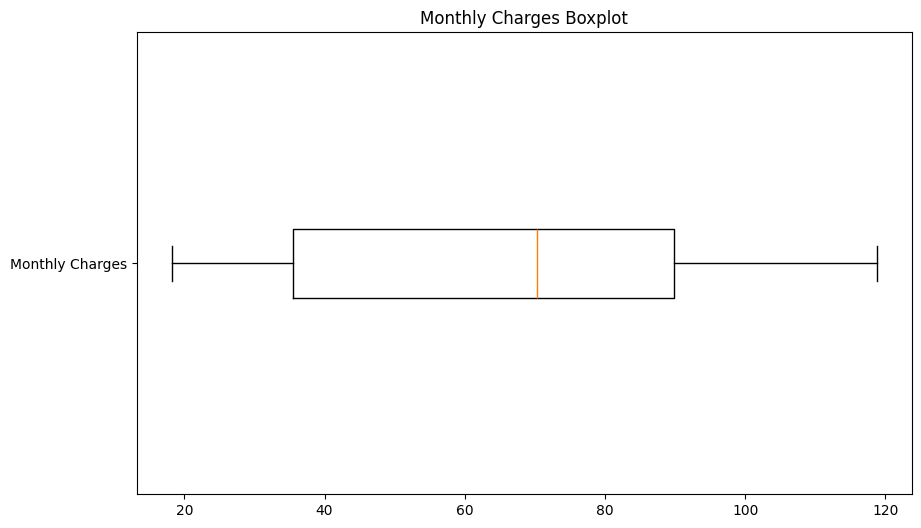

In [22]:
plt.figure(figsize=(10, 6))
plt.boxplot(df['MonthlyCharges'], vert = False, labels = ['Monthly Charges'])
plt.title("Monthly Charges Boxplot")
plt.show()

In [23]:
from scipy import stats
z_score = stats.zscore(df['tenure'])
df[abs(z_score > 3)]['tenure'].count()

np.int64(0)

In [24]:
z_score = stats.zscore(df['MonthlyCharges'])
df[abs(z_score > 3)]['MonthlyCharges'].count()

np.int64(0)

Numericals Columns have been cleaned and there is no outlier as we confirmed by both of the method IQR & Z-Score
Now turn for Catagorical Columns

In [25]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [26]:
df = df.drop('customerID', axis=1)

In [27]:
df.shape

(7043, 20)

In [28]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [29]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [30]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


In [31]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']])
df['Contract'] = encoder.fit_transform(df[['Contract']])

In [32]:
catagorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
df = pd.get_dummies(df, columns = catagorical_cols, drop_first=True)


In [33]:
df.shape

(7043, 31)

In [34]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [35]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
X_train[numeric_cols].head(2)


,tenure,MonthlyCharges,TotalCharges
3738,0.102371,-0.521976,-0.262257
3151,-0.711743,0.337478,-0.503635


In [37]:
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
0,73.464679
1,26.535321


In [38]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [39]:
y_train_resampled.value_counts(normalize=True) * 100

,proportion
Churn,
0,50.0
1,50.0


## 4. Feature Engineering & Encoding

Machine learning models cannot process raw text or categorical data directly. In this section, we:
- Encode categorical columns (such as Gender, Contract, PaymentMethod) into numerical format.
- Scale features to optimize model performance.

In [40]:
def tenure_group(t):
  if t <= 12:
    return 'New'
  elif t<= 48:
    return 'Established'
  else:
    return 'Loyal'
X_train_resampled['tenureGroup'] = X_train_resampled['tenure'].apply(tenure_group)
X_test['tenureGroup'] = X_test['tenure'].apply(tenure_group)


In [41]:
X_train_resampled = pd.get_dummies(X_train_resampled, columns=['tenureGroup'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['tenureGroup'], drop_first=True)

In [42]:
services_cols = ['OnlineSecurity_Yes', 'OnlineBackup_Yes',
                 'DeviceProtection_Yes', 'TechSupport_Yes',
                 'StreamingTV_Yes', 'StreamingMovies_Yes']
X_train_resampled['TotalServices'] = X_train_resampled[services_cols].sum(axis=1)
X_test['TotalServices'] = X_test[services_cols].sum(axis=1)

In [43]:
X_train_resampled['ExpectedTotal'] = X_train_resampled['TotalServices'] * X_train_resampled['MonthlyCharges']
X_train_resampled['ChargeDifference'] = X_train_resampled['TotalCharges'] - X_train_resampled['ExpectedTotal']

X_test['ExpectedTotal'] = X_test['TotalServices'] * X_test['MonthlyCharges']
X_test['ChargeDifference'] = X_test['TotalCharges'] - X_test['ExpectedTotal']
X_train_resampled['ChargeDifference'].describe()

,ChargeDifference
count,8278.000000
mean,-1.490152
std,1.869614
min,-9.515944
25%,-2.296534
50%,-0.978506
75%,-0.472475
max,3.331116


In [44]:
X_train_resampled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_1.0,Contract_2.0,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TotalServices,ExpectedTotal,ChargeDifference
0,0,0.102371,-0.521976,-0.262257,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,3,-1.565927,1.303670
1,0,-0.711743,0.337478,-0.503635,True,True,True,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,1,0.337478,-0.841113
2,0,-0.793155,-0.809013,-0.749883,True,True,True,False,True,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,True,3,-2.427040,1.677157
3,0,-0.263980,0.284384,-0.172722,False,True,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,True,False,True,True,True,False,False,4,1.137537,-1.310259
4,0,-1.281624,-0.676279,-0.989374,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,0,-0.000000,-0.989374


## 5. Model Training, Hyperparameter Tuning & Evaluation

In this section, we implement a comprehensive model selection and optimization pipeline:
- **Baseline Training:** We train multiple classification algorithms (Logistic Regression, Random Forest, XGBoost, Decision Tree, KNN, SVM, and Naive Bayes) to evaluate initial performance.
- **Hyperparameter Tuning:** We identify the best-performing model and use tuning techniques (like Grid Search) to find its optimal parameters.
- **Final Training:** We train the final model using these optimized parameters and evaluate it using metrics like Classification Report, Confusion Matrix, and ROC-AUC.

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [46]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(random_state=42),
    'Naive Bayes': GaussianNB()
}


In [47]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

for name, model in models.items():
    scores = cross_val_score(model, X_train_resampled, y_train_resampled, cv=5)
    print(f"{name}: {scores.mean():.4f} +/- {scores.std():.4f}")

Logistic Regression: 0.7962 +/- 0.0271
Random Forest: 0.8389 +/- 0.0235
XGBoost: 0.8250 +/- 0.0463
Decision Tree: 0.7751 +/- 0.0300
K-Nearest Neighbors: 0.8031 +/- 0.0216
Support Vector Machine: 0.7839 +/- 0.0121
Naive Bayes: 0.7183 +/- 0.0126


In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_model = RandomForestClassifier(random_state=42)

param_dict = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced', 'balanced_subsample', {0:1, 1:5}, {0:1, 1:10}],
    'criterion': ['gini', 'entropy', 'log_loss']
}

random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_dict, n_iter=20, cv=3, scoring='f1', verbose=2, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'log_loss', 'class_weight': 'balanced_subsample', 'bootstrap': True}
Best score: 0.64097390947438


In [49]:
model = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=10,
    criterion='log_loss',
    class_weight='balanced_subsample',
    bootstrap=True,
    random_state=42
)

In [50]:
model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(class_weight='balanced_subsample', criterion='log_loss',
                       max_depth=10, min_samples_leaf=2, n_estimators=200,
                       random_state=42)

In [51]:
y_pred = model.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_pred))

Accuracy:  0.7558552164655784
Precision:  0.5281954887218046
Recall:  0.7513368983957219
F1 Score:  0.6203090507726269
ROC AUC Score:  0.7544124105505179


In [53]:
y_proba = model.predict_proba(X_test)[:,1]

In [54]:
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

In [56]:
# Find best threshold: recall > 90 and maximize the precision
best_recall = 0
best_precision = 0
best_threshold = None
for i in range(len(thresholds)):
    if recall[i] > 0.9 and precision[i] > best_precision:
        best_recall = recall[i]
        best_precision = precision[i]
        best_threshold = thresholds[i]
print("Best threshold: ", best_threshold)
print("Best precision: ", best_precision)
print("Best recall: ", best_recall)


Best threshold:  0.3088583125348903
Best precision:  0.4505347593582888
Best recall:  0.9010695187165776


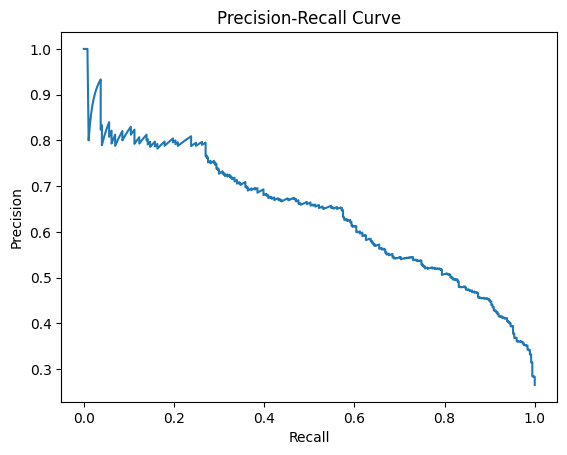

In [57]:
from matplotlib import pyplot as plt
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

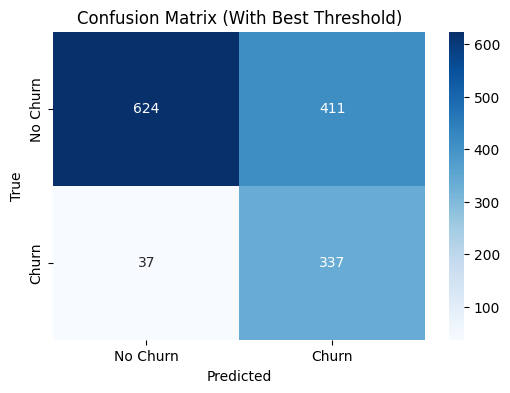

              precision    recall  f1-score   support

           0       0.94      0.60      0.74      1035
           1       0.45      0.90      0.60       374

    accuracy                           0.68      1409
   macro avg       0.70      0.75      0.67      1409
weighted avg       0.81      0.68      0.70      1409



In [67]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Model ki probabilities nikalein (agar pehle se nahi nikali)
# y_prob = model.predict_proba(X_test)[:, 1]

# 2. Apna Best Threshold apply karein
best_threshold = 0.3088583125348903
y_pred_custom = (y_proba >= best_threshold).astype(int)

# 3. Ab Confusion Matrix banayein
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix (With Best Threshold)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 4. Check karne ke liye report bhi print kar lein ke 90% recall aa raha hai ya nahi
print(classification_report(y_test, y_pred_custom))

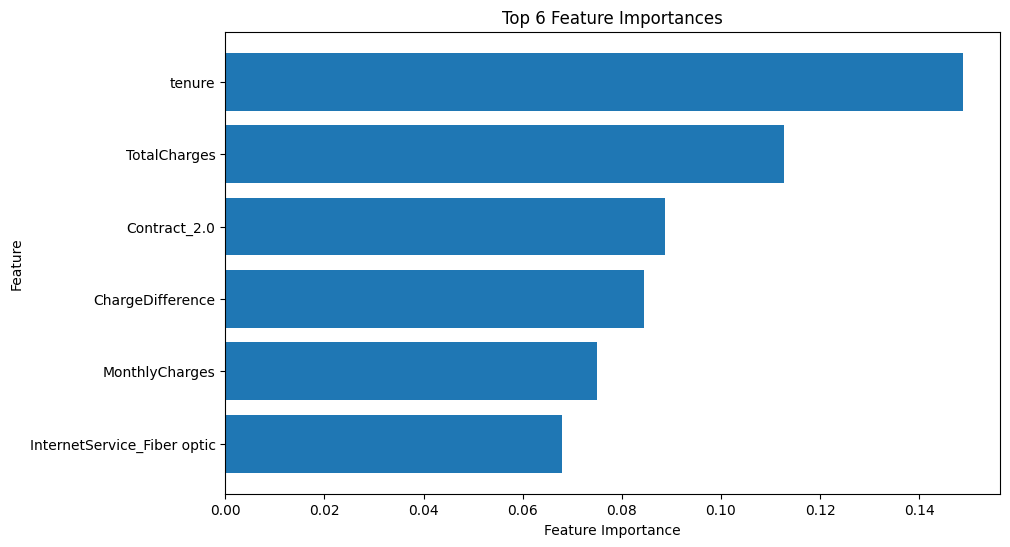

In [64]:
import matplotlib.pyplot as plt

# Sort indices
sorted_idx = feature_importances.argsort()

# Sirf last 6 indices (top 6 highest importances) lo
top_6_idx = sorted_idx[-6:]

plt.figure(figsize=(10, 6))
plt.barh(feature_names[top_6_idx], feature_importances[top_6_idx])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 6 Feature Importances')
plt.show()

In [75]:
import pickle

# 1. Model ko .pkl file mein save karein
model_filename = 'churn_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model successfully saved as {model_filename}")

# 2. Agar aap Google Colab use kar rahe hain aur file ko apne local PC par download karna chahte hain:
from google.colab import files
files.download(model_filename)

Model successfully saved as churn_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6. Conclusion & Deployment Readiness (.pkl Export)

### Key Findings:
- Short-term contracts and higher monthly charges significantly increase the likelihood of customer churn.
- Higher tenure correlates with better customer retention.

### Model Export:
Finally, we serialize and save our trained model into a `.pkl` file format for easy deployment in production environments or web apps (Streamlit / Flask).